Используя базу "Пассажиры автобуса", подготовьте данные для обучения нейронной сети, классифицирующей изображение на два класса:
- входящий пассажир
- выходящий пассажир

Добейтесь точности работы модели на проверочной выборке не ниже 85%

Ссылка на датасет: https://storage.yandexcloud.net/aiueducation/Content/base/l4/bus.zip

Информацию о загрузке изображений и преобразовании их в numnpy-массивы вы можете найти в Базе знаний:


In [1]:
# Подключение класса для создания нейронной сети прямого распространения
from tensorflow.keras.models import Sequential
# Подключение класса для создания полносвязного слоя
from tensorflow.keras.layers import Dense
# Подключение оптимизатора
from tensorflow.keras.optimizers import Adam
# Подключение утилит для to_categorical
from tensorflow.keras import utils
# Подключение библиотеки для загрузки изображений
from tensorflow.keras.preprocessing import image
# Подключение библиотеки для работы с массивами
import numpy as np
# Подключение модуля для работы с файлами
import os
# Подключение библиотек для отрисовки изображений
import matplotlib.pyplot as plt
# Вывод изображения в ноутбуке, а не в консоли или файле
%matplotlib inline
from sklearn.model_selection import train_test_split
import zipfile
import os
from sklearn.utils import shuffle
from tensorflow.keras.layers import Dropout

In [2]:
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l4/bus.zip', None, quiet=True)

'bus.zip'

In [3]:
!unzip -qo bus.zip

In [4]:
zip_path = "bus.zip"
extract_dir = "bus"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Путь к директории с базой
base_dir = "bus"

# Создание пустого списка для загрузки изображений и меток
x_data = []
y_data = []

# Параметры изображений
img_height = 64
img_width = 64

# Загрузка изображений и меток
for folder in os.listdir(base_dir):
    folder_path = os.path.join(base_dir, folder)
    for img_file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_file)
        img_array = image.img_to_array(
            image.load_img(img_path, target_size=(img_height, img_width), color_mode='grayscale')
        )
        x_data.append(img_array)
        y_data.append(0 if folder == 'Входящий' else 1)

# Преобразование в numpy-массив
x_data = np.array(x_data)
y_data = np.array(y_data)

x_data, y_data = shuffle(x_data, y_data, random_state=42)
# Сначала делим на train+val и test
x_train_val, x_test, y_train_val, y_test = train_test_split(
    x_data, y_data, test_size=0.2, random_state=42, stratify=y_data
)

# Затем делим train_val на train и validation
x_train, x_val, y_train, y_val = train_test_split(
    x_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

# Вывод размерностей
print('Размер массива x_train:', x_train.shape)
print('Размер массива y_train:', y_train.shape)
print('Размер массива x_val:', x_val.shape)
print('Размер массива y_val:', y_val.shape)
print('Размер массива x_test:', x_test.shape)
print('Размер массива y_test:', y_test.shape)

Размер массива x_train: (5811, 64, 64, 1)
Размер массива y_train: (5811,)
Размер массива x_val: (1453, 64, 64, 1)
Размер массива y_val: (1453,)
Размер массива x_test: (1817, 64, 64, 1)
Размер массива y_test: (1817,)


In [5]:
x_train = x_train.reshape(x_train.shape[0], -1)
x_val   = x_val.reshape(x_val.shape[0], -1)
x_test  = x_test.reshape(x_test.shape[0], -1)
x_val = x_val.astype('float32') / 255
x_train = x_train.astype('float32') / 255
x_test =  x_test.astype('float32') / 255
print(f'Форма обучающих данных: {x_train.shape}')
print(f'Форма тестовых данных: {x_test.shape}')
print(f'Форма валидационных данных: {x_val.shape}')

Форма обучающих данных: (5811, 4096)
Форма тестовых данных: (1817, 4096)
Форма валидационных данных: (1453, 4096)


In [6]:
CLASS_COUNT = 2

In [22]:
model = Sequential()

model.add(Dense(128, input_dim = img_height*img_width, activation = 'relu'))

model.add(Dense(64, activation='relu'))


model.add(Dense(1, activation='sigmoid'))

# Компиляция модели
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Вывод структуры модели
print(model.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 532,737 (2.03 MB)

 Trainable params: 532,737 (2.03 MB)

 Non-trainable params: 0 (0.00 B)

None


In [8]:
print(y_train.shape)
print(x_train.shape)

(5811,)
(5811, 4096)


In [23]:
history = model.fit(x_train, y_train, batch_size = 128, validation_data=(x_val, y_val),epochs = 20, verbose = 1)

Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7095 - loss: 0.6232 - val_accuracy: 0.7151 - val_loss: 0.5603
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7374 - loss: 0.5513 - val_accuracy: 0.7392 - val_loss: 0.5461
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7513 - loss: 0.5202 - val_accuracy: 0.7350 - val_loss: 0.5360
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7697 - loss: 0.4935 - val_accuracy: 0.7722 - val_loss: 0.4783
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7851 - loss: 0.4659 - val_accuracy: 0.7481 - val_loss: 0.5395
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7907 - loss: 0.4480 - val_accuracy: 0.7798 - val_loss: 0.4518
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7969 - loss: 0.4458 - val_accuracy: 0.8004 - val_loss: 0.4501
Epoch 8/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8018 - loss: 0.4264 - val_accuracy: 0.8011 - v

In [24]:
max(history.history['val_accuracy'])

0.8768066167831421

In [16]:
model.evaluate(x_test, y_test)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8437 - loss: 0.3308


[0.3308159410953522, 0.8436983823776245]

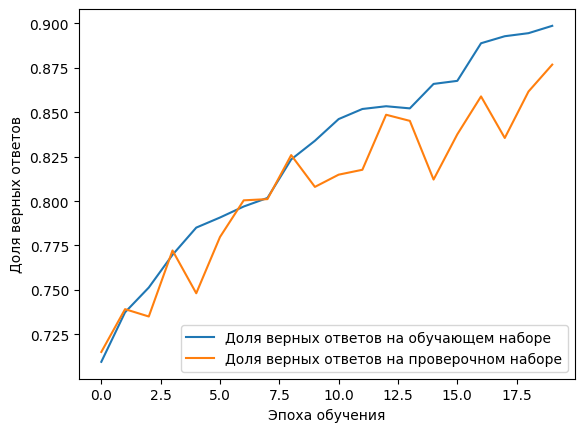

In [25]:
# Рисование графиков
import matplotlib.pyplot as plt

# Отрисовка графика точности на обучающей выборке
plt.plot(history.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')

# Отрисовка графика точности на проверочной выборке
plt.plot(history.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')

# Отрисовка подписей осей
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')

# Отрисовка легенды
plt.legend()

# Вывод графика
plt.show()